# Exploratory Data Analysis

This notebook conducts an exploratory time-series analysis for retail sales forecasting using the Favorita dataset.

**Target Series Definition**:
- **Store**: 1 (located in Quito, Pichincha)
- **Family**: GROCERY I
- **Target**: Daily `sales`

In [1]:
import pandas as pd

df = pd.read_csv('../data/train.csv', parse_dates=['date'])


In [2]:
print("size of df:", df.shape)
df.head()

size of df: (3000888, 6)
Out[0]: 
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [4]:
df['date'].min(), df['date'].max()

Out[0]: (Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))


(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))


Check granularity and missing values

In [5]:
df['store_nbr'].nunique(), df['family'].nunique()

Out[0]: (54, 33)


(54, 33)


In [6]:
df.isnull().sum()

Out[0]: 
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


## Target Series

We isolate the forecasting target series (`store_nbr == 1` and `family == 'GROCERY I'`) into a dedicated dataframe `target_df` with columns `date`, `sales`, and `onpromotion`, sorted chronologically. We also preserve `slice_df` as a reference.

In [7]:
# Filter to Store 1, GROCERY I and keep date, sales, onpromotion
target_df = (
    df[(df['store_nbr'] == 1) & (df['family'] == 'GROCERY I')][['date', 'sales', 'onpromotion']]
    .sort_values('date')
    .reset_index(drop=True)
)

# Preserve slice_df for backward compatibility with initial exploration
slice_df = target_df.copy()

print('Target dataframe shape:', target_df.shape)
target_df.head()

Target dataframe shape: (1684, 3)
Out[0]: 
        date   sales  onpromotion
0 2013-01-01     0.0            0
1 2013-01-02  2652.0            0
2 2013-01-03  2121.0            0
3 2013-01-04  2056.0            0
4 2013-01-05  2216.0            0


,date,sales,onpromotion
0,2013-01-01,0.0,0
1,2013-01-02,2652.0,0
2,2013-01-03,2121.0,0
3,2013-01-04,2056.0,0
4,2013-01-05,2216.0,0


In [8]:
# Target series summary statistics
target_df.describe()

Out[0]: 
                             date        sales  onpromotion
count                        1684  1684.000000  1684.000000
mean   2015-04-24 08:27:04.703088  2223.172803    17.560570
min           2013-01-01 00:00:00     0.000000     0.000000
25%           2014-02-26 18:00:00  1873.500000     0.000000
50%           2015-04-24 12:00:00  2283.500000     6.000000
75%           2016-06-19 06:00:00  2649.000000    28.000000
max           2017-08-15 00:00:00  9065.000000   167.000000
std                           NaN   779.285352    24.741069


,date,sales,onpromotion
count,1684,1684.000000,1684.000000
mean,2015-04-24 08:27:04.703088,2223.172803,17.560570
min,2013-01-01 00:00:00,0.000000,0.000000
25%,2014-02-26 18:00:00,1873.500000,0.000000
50%,2015-04-24 12:00:00,2283.500000,6.000000
75%,2016-06-19 06:00:00,2649.000000,28.000000
max,2017-08-15 00:00:00,9065.000000,167.000000
std,NaN,779.285352,24.741069


Plotting sliced DataFrame

Out[0]: <Axes: title={'center': 'Store 1 - Grocery I Sales'}, xlabel='date'>


<Axes: title={'center': 'Store 1 - Grocery I Sales'}, xlabel='date'>


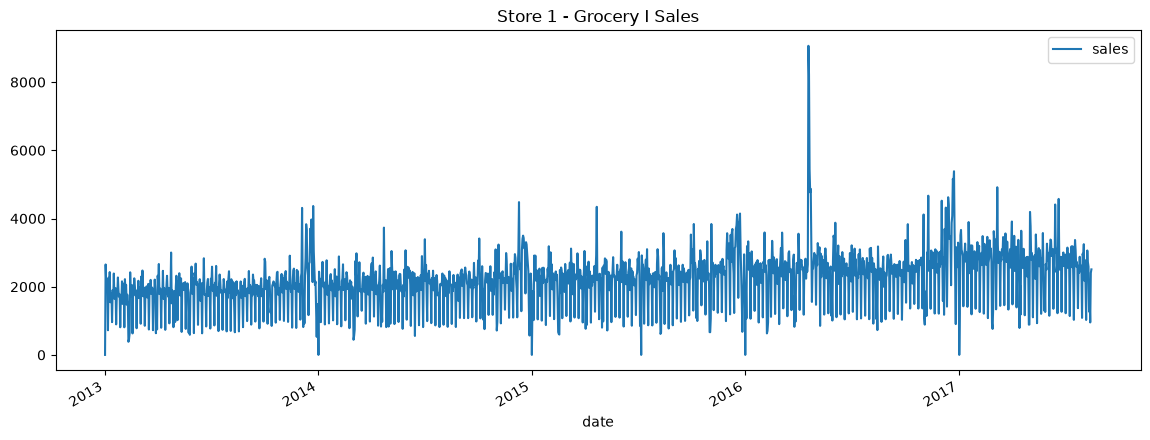

In [9]:
slice_df.plot(x='date',
              y='sales',
              figsize=(14, 5),
              title='Store 1 - Grocery I Sales')

zooming into year 2016 to inspect that spike

Out[0]: <Axes: xlabel='date'>


<Axes: xlabel='date'>


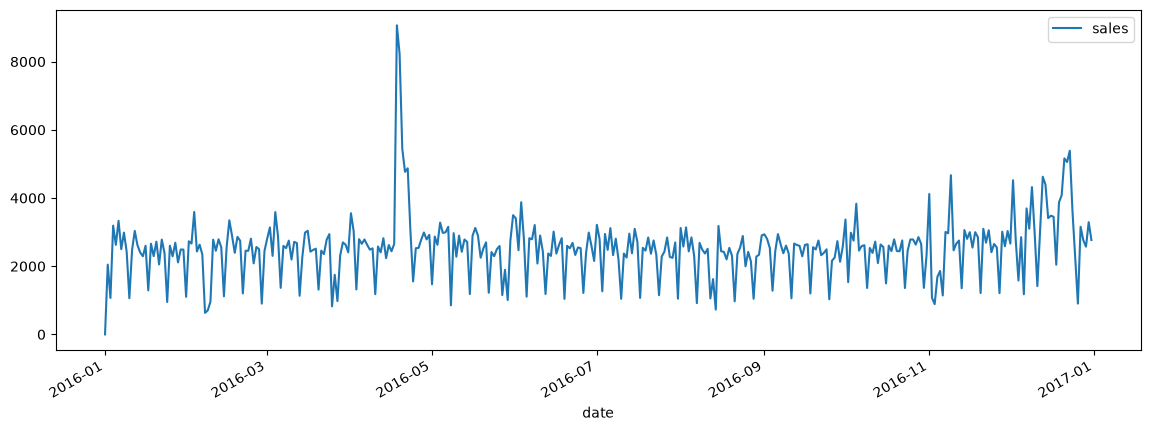

In [10]:
slice_df[(slice_df.date >= '2016-01-01')
         & (slice_df.date <= '2016-12-31')].plot(x='date',
                                                 y='sales',
                                                 figsize=(14, 5))

Out[0]: <Axes: xlabel='date'>


<Axes: xlabel='date'>


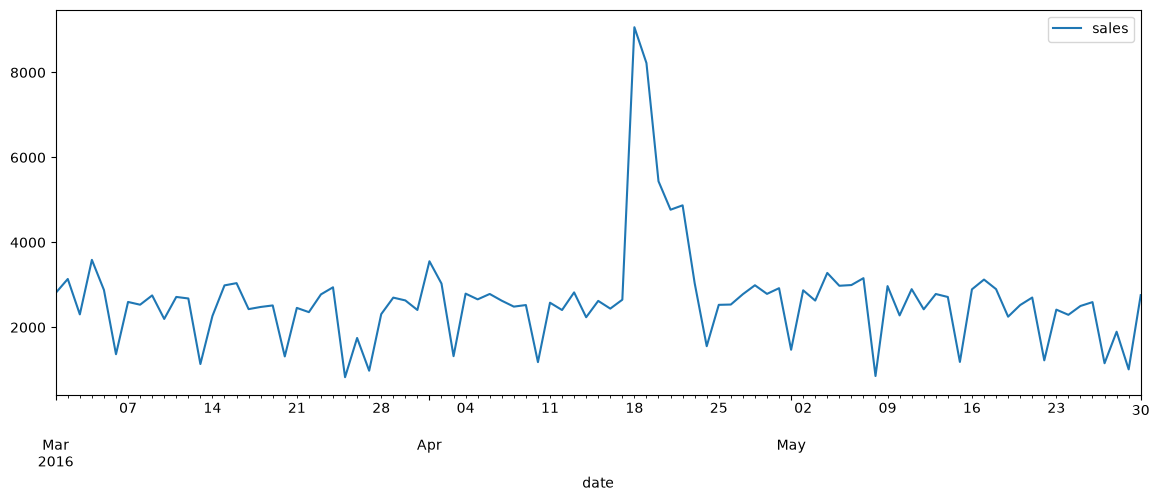

In [11]:
slice_df[(slice_df.date >= '2016-03-01')
         & (slice_df.date <= '2016-05-30')].plot(x='date',
                                                 y='sales',
                                                 figsize=(14, 5))

### Zooming into a Typical Month

To observe short-term daily fluctuations and weekly patterns, we zoom into a single representative month (May 2017).

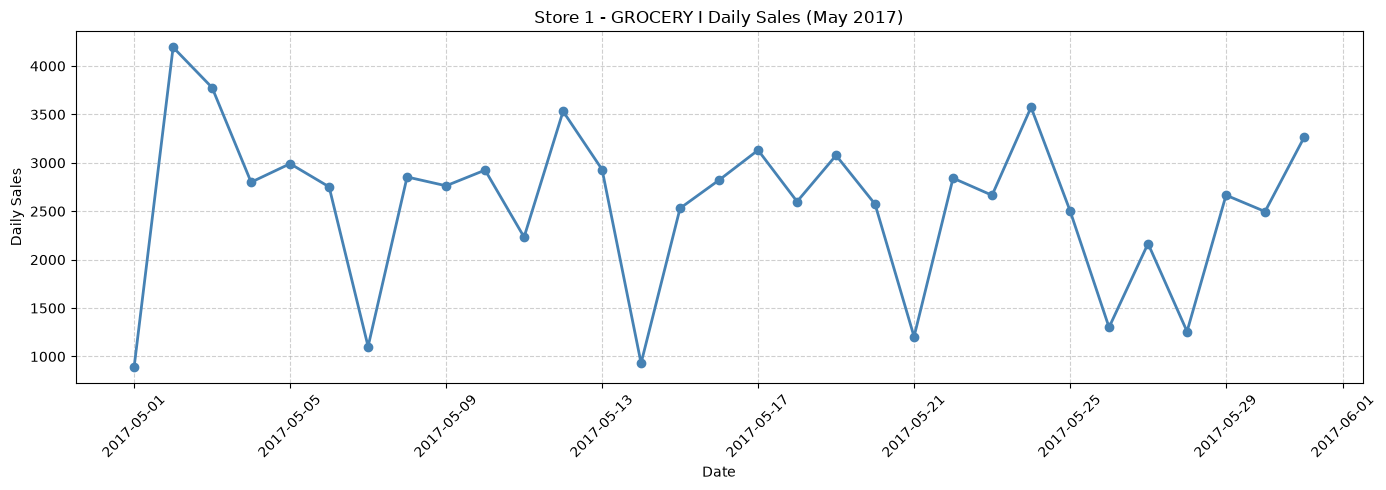

In [12]:
import matplotlib.pyplot as plt

# Zoom into May 2017 to observe day-to-day fluctuations
may_2017 = target_df[(target_df['date'] >= '2017-05-01') & (target_df['date'] <= '2017-05-31')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(may_2017['date'], may_2017['sales'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Store 1 - GROCERY I Daily Sales (May 2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales')
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Missing Dates

Time series models, lag features, and rolling windows require a continuous time index. Here we construct a complete daily calendar from the start date to the end date of the target series and identify absent dates.

In [13]:
# Generate a complete daily calendar
full_calendar = pd.date_range(start=target_df['date'].min(), end=target_df['date'].max(), freq='D')
missing_dates = full_calendar.difference(target_df['date'])

print(f"Total days in complete calendar: {len(full_calendar)}")
print(f"Days recorded in dataset:        {len(target_df)}")
print(f"Number of missing dates:         {len(missing_dates)}")
print("\nMissing calendar dates:")
for d in missing_dates:
    print(f" - {d.strftime('%Y-%m-%d')}")

Total days in complete calendar: 1688
Days recorded in dataset:        1684
Number of missing dates:         4

Missing calendar dates:
 - 2013-12-25
 - 2014-12-25
 - 2015-12-25
 - 2016-12-25


In [14]:
# Compare missing dates against holidays_events.csv
holidays_df = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
missing_in_holidays = holidays_df[holidays_df['date'].isin(missing_dates)]
missing_in_holidays[['date', 'type', 'locale', 'locale_name', 'description', 'transferred']]

Out[0]: 
          date     type    locale locale_name description  transferred
89  2013-12-25  Holiday  National     Ecuador     Navidad        False
155 2014-12-25  Holiday  National     Ecuador     Navidad        False
208 2015-12-25  Holiday  National     Ecuador     Navidad        False
294 2016-12-25  Holiday  National     Ecuador     Navidad        False


,date,type,locale,locale_name,description,transferred
89,2013-12-25,Holiday,National,Ecuador,Navidad,False
155,2014-12-25,Holiday,National,Ecuador,Navidad,False
208,2015-12-25,Holiday,National,Ecuador,Navidad,False
294,2016-12-25,Holiday,National,Ecuador,Navidad,False


### Findings & Modeling Treatment for Missing Dates

- **Data shows**: Exactly 4 dates are absent from the entire series: December 25 in 2013, 2014, 2015, and 2016. In `holidays_events.csv`, all 4 dates correspond to national `Navidad` (Christmas Day) with `transferred == False`.
- **Interpretation**: The four missing dates correspond to Christmas Day. Their treatment will be explicitly defined during the time-series preparation stage rather than being silently imputed during EDA.

## Weekly Seasonality

Grocery sales typically exhibit recurring intra-week behavioral cycles. We evaluate average and median sales across days of the week.

In [15]:
# Compute day-of-week attributes
target_df['day_name'] = target_df['date'].dt.day_name()
target_df['day_of_week'] = target_df['date'].dt.dayofweek  # 0=Monday, 6=Sunday

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_stats = (
    target_df.groupby(['day_of_week', 'day_name'])['sales']
    .agg(count='count', mean_sales='mean', median_sales='median', std_sales='std')
    .reset_index()
)
weekday_stats

Out[0]: 
   day_of_week   day_name  count   mean_sales  median_sales   std_sales
0            0     Monday    241  2383.493776        2336.0  704.867955
1            1    Tuesday    242  2408.991736        2384.0  732.843040
2            2  Wednesday    240  2770.362500        2687.0  596.370457
3            3   Thursday    240  2229.045833        2149.5  521.601992
4            4     Friday    240  2413.645833        2356.5  699.768464
5            5   Saturday    241  2322.962656        2289.0  451.130657
6            6     Sunday    240  1031.075000        1006.5  281.185540


,day_of_week,day_name,count,mean_sales,median_sales,std_sales
0,0,Monday,241,2383.493776,2336.0,704.867955
1,1,Tuesday,242,2408.991736,2384.0,732.843040
2,2,Wednesday,240,2770.362500,2687.0,596.370457
3,3,Thursday,240,2229.045833,2149.5,521.601992
4,4,Friday,240,2413.645833,2356.5,699.768464
5,5,Saturday,241,2322.962656,2289.0,451.130657
6,6,Sunday,240,1031.075000,1006.5,281.185540


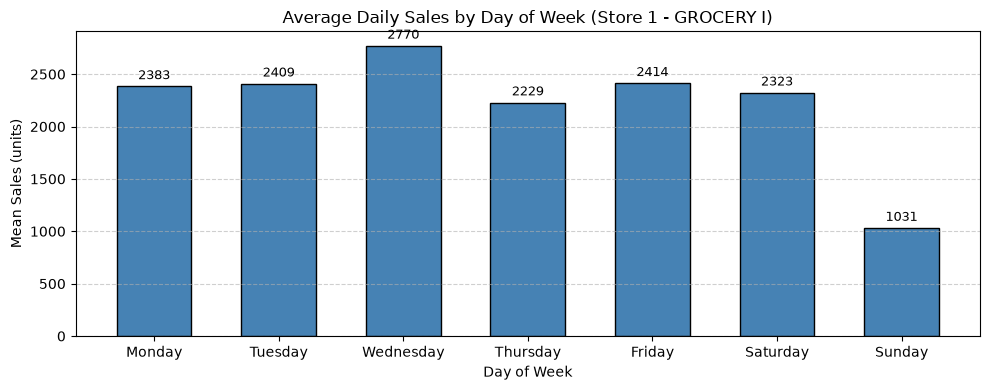

In [16]:
# Visualizing average sales by weekday
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(weekday_stats['day_name'], weekday_stats['mean_sales'], color='steelblue', edgecolor='black', width=0.6)
ax.set_title('Average Daily Sales by Day of Week (Store 1 - GROCERY I)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Mean Sales (units)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

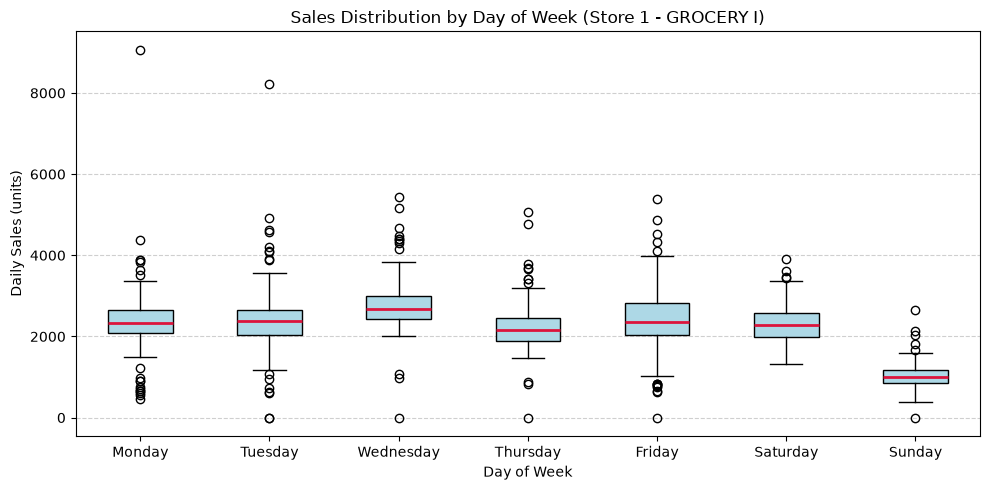

In [17]:
# Sales distribution by weekday using matplotlib boxplot
weekday_sales_data = [target_df[target_df['day_name'] == day]['sales'].values for day in weekday_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    weekday_sales_data,
    tick_labels=weekday_order,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='crimson', linewidth=2)
)
ax.set_title('Sales Distribution by Day of Week (Store 1 - GROCERY I)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Daily Sales (units)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Weekly Seasonality Observations

- **Midweek peak**: Wednesday has the highest mean sales (~2,770 units) and median sales (~2,687 units).
- **Sunday drop**: Sunday sales are by far the lowest, averaging ~1,031 units (median ~1,006 units) — less than half of normal weekday sales.
- **Weekday stability**: Monday, Tuesday, Thursday, Friday, and Saturday maintain steady mean volumes between ~2,229 and ~2,414 units.
- **Modeling implication**: Weekly day-of-week seasonality is prominent and will be an essential feature (e.g., day-of-week indicators or Fourier terms) in any forecasting model.

## Monthly Patterns

We group daily sales by month of the year to inspect longer-term intra-year patterns.

In [18]:
# Monthly aggregation
target_df['month'] = target_df['date'].dt.month
target_df['month_name'] = target_df['date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_stats = (
    target_df.groupby(['month', 'month_name'])['sales']
    .agg(count='count', mean_sales='mean', median_sales='median', std_sales='std')
    .reset_index()
)
monthly_stats

Out[0]: 
    month month_name  count   mean_sales  median_sales    std_sales
0       1    January    155  2109.903226        2208.0   746.221171
1       2   February    141  2091.872340        2193.0   748.043418
2       3      March    155  2214.729032        2289.0   743.179387
3       4      April    150  2343.973333        2308.0  1086.937308
4       5        May    155  2183.412903        2295.0   721.858332
5       6       June    150  2268.526667        2326.5   713.742116
6       7       July    155  2178.774194        2275.0   648.262238
7       8     August    139  2033.323741        2155.0   640.865902
8       9  September    120  2126.658333        2251.5   535.530107
9      10    October    124  2224.822581        2292.5   607.689414
10     11   November    120  2201.700000        2307.0   718.067874
11     12   December    120  2771.866667        2830.0  1039.683646


,month,month_name,count,mean_sales,median_sales,std_sales
0,1,January,155,2109.903226,2208.0,746.221171
1,2,February,141,2091.872340,2193.0,748.043418
2,3,March,155,2214.729032,2289.0,743.179387
3,4,April,150,2343.973333,2308.0,1086.937308
4,5,May,155,2183.412903,2295.0,721.858332
5,6,June,150,2268.526667,2326.5,713.742116
6,7,July,155,2178.774194,2275.0,648.262238
7,8,August,139,2033.323741,2155.0,640.865902
8,9,September,120,2126.658333,2251.5,535.530107
9,10,October,124,2224.822581,2292.5,607.689414


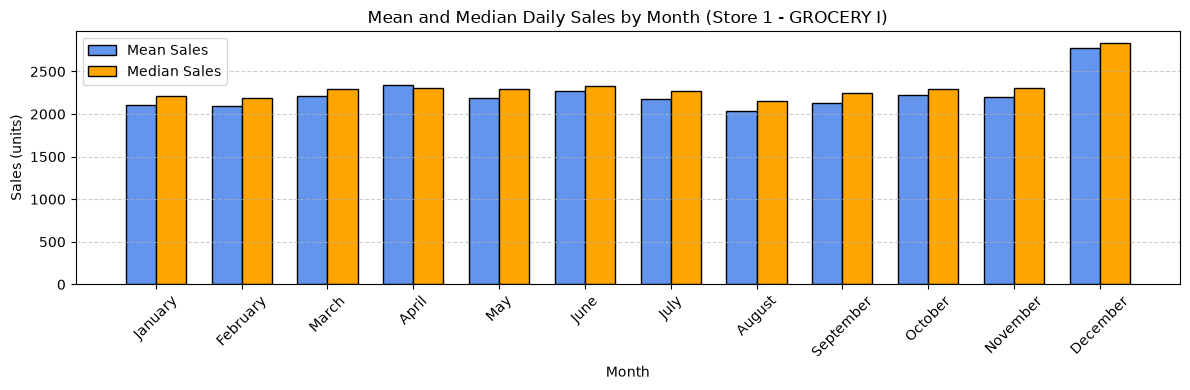

In [19]:
import numpy as np

# Comparison of mean vs median monthly sales
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(monthly_stats))
width = 0.35

ax.bar(x - width/2, monthly_stats['mean_sales'], width, label='Mean Sales', color='cornflowerblue', edgecolor='black')
ax.bar(x + width/2, monthly_stats['median_sales'], width, label='Median Sales', color='orange', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(monthly_stats['month_name'], rotation=45)
ax.set_title('Mean and Median Daily Sales by Month (Store 1 - GROCERY I)')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (units)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Patterns Observations

- **December peak**: December shows the highest sales (mean ~2,772 units, median ~2,830 units), consistent with end-of-year holiday buying.
- **April elevation**: April shows an elevated mean (~2,344 units) and the highest standard deviation ($\sigma \approx 1,087$), driven primarily by the April 2016 earthquake surge.
- **General baseline**: Across remaining months, sales remain relatively uniform, hovering between ~2,033 and ~2,269 units.
- **Caution**: We cannot definitively conclude that true monthly seasonality exists purely because monthly sample averages differ; differences across months are modest and partially confounded by calendar shifts and isolated one-off events.

## Promotions

The dataset provides the count of items in the `GROCERY I` family on promotion each day (`onpromotion`). We compare sales between days without active promotions and days with at least one promotion.

In [20]:
# Segment into no promotion vs at least one promotion
target_df['has_promotion'] = target_df['onpromotion'] > 0

promo_stats = (
    target_df.groupby('has_promotion')['sales']
    .agg(count='count', mean_sales='mean', median_sales='median', std_sales='std')
    .reset_index()
)
promo_stats['promotion_status'] = promo_stats['has_promotion'].map({
    False: 'No Promotion (0 items)',
    True: 'On Promotion (>= 1 item)'
})
promo_stats[['promotion_status', 'count', 'mean_sales', 'median_sales', 'std_sales']]

Out[0]: 
           promotion_status  count   mean_sales  median_sales   std_sales
0    No Promotion (0 items)    574  1873.156794        1965.0  619.951625
1  On Promotion (>= 1 item)   1110  2404.172072        2454.5  791.722898


,promotion_status,count,mean_sales,median_sales,std_sales
0,No Promotion (0 items),574,1873.156794,1965.0,619.951625
1,On Promotion (>= 1 item),1110,2404.172072,2454.5,791.722898


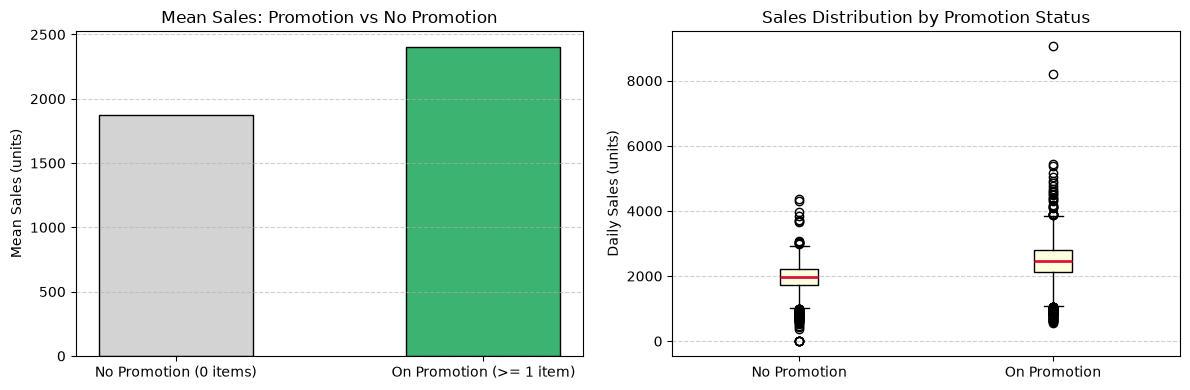

In [21]:
# Visualizing promotion comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of mean sales
ax1.bar(promo_stats['promotion_status'], promo_stats['mean_sales'], color=['lightgray', 'mediumseagreen'], edgecolor='black', width=0.5)
ax1.set_title('Mean Sales: Promotion vs No Promotion')
ax1.set_ylabel('Mean Sales (units)')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Distribution boxplot
promo_data = [
    target_df[~target_df['has_promotion']]['sales'].values,
    target_df[target_df['has_promotion']]['sales'].values
]
ax2.boxplot(
    promo_data,
    tick_labels=['No Promotion', 'On Promotion'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow', color='black'),
    medianprops=dict(color='crimson', linewidth=2)
)
ax2.set_title('Sales Distribution by Promotion Status')
ax2.set_ylabel('Daily Sales (units)')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Promotion Observations

- **Summary**: Days with at least one active promotion (1,110 days) show higher average sales (~2,404 units, median ~2,455 units) than days with zero promotions (574 days, mean ~1,873 units, median ~1,965 units).
- **Important Caution on Causality**: This is observational time-series data. Promotions are associated with higher sales, but we cannot assert that promotions cause higher sales (for instance, retailers may schedule promotions during peak shopping periods or on items with seasonal demand).

## Holidays

We incorporate `holidays_events.csv` to investigate how holidays correlate with Store 1 sales. Store 1 is located in Quito, Pichincha, so relevant holidays include:
1. `National` holidays (affecting all of Ecuador)
2. `Regional` holidays where `locale_name == 'Pichincha'`
3. `Local` holidays where `locale_name == 'Quito'`

We also account for `transferred == True` (holidays officially moved to another date) and `type == 'Work Day'` (workdays compensating for bridge days).

In [22]:
# Load store metadata to verify Store 1 location
stores_df = pd.read_csv('../data/stores.csv')
store_1_meta = stores_df[stores_df['store_nbr'] == 1].iloc[0]
print(f"Store 1: City={store_1_meta['city']}, State={store_1_meta['state']}, Type={store_1_meta['type']}")

# Filter holidays applicable to Store 1
relevant_holidays = holidays_df[
    (holidays_df['locale'] == 'National') |
    ((holidays_df['locale'] == 'Regional') & (holidays_df['locale_name'] == store_1_meta['state'])) |
    ((holidays_df['locale'] == 'Local') & (holidays_df['locale_name'] == store_1_meta['city']))
].copy()

# Identify effective holidays (official days off: not transferred, and not compensatory work days)
effective_holidays = relevant_holidays[
    (~relevant_holidays['transferred']) &
    (relevant_holidays['type'] != 'Work Day')
]
effective_holiday_dates = set(effective_holidays['date'])

# Flag holiday status in target_df
target_df['is_holiday'] = target_df['date'].isin(effective_holiday_dates)

holiday_comparison = (
    target_df.groupby('is_holiday')['sales']
    .agg(count='count', mean_sales='mean', median_sales='median', std_sales='std')
    .reset_index()
)
holiday_comparison['holiday_label'] = holiday_comparison['is_holiday'].map({
    False: 'Non-Holiday',
    True: 'Holiday'
})
holiday_comparison[['holiday_label', 'count', 'mean_sales', 'median_sales', 'std_sales']]

Store 1: City=Quito, State=Pichincha, Type=D
Out[0]: 
  holiday_label  count   mean_sales  median_sales    std_sales
0   Non-Holiday   1545  2237.122977        2294.0   692.052962
1       Holiday    139  2068.115108        2011.0  1421.725687


,holiday_label,count,mean_sales,median_sales,std_sales
0,Non-Holiday,1545,2237.122977,2294.0,692.052962
1,Holiday,139,2068.115108,2011.0,1421.725687


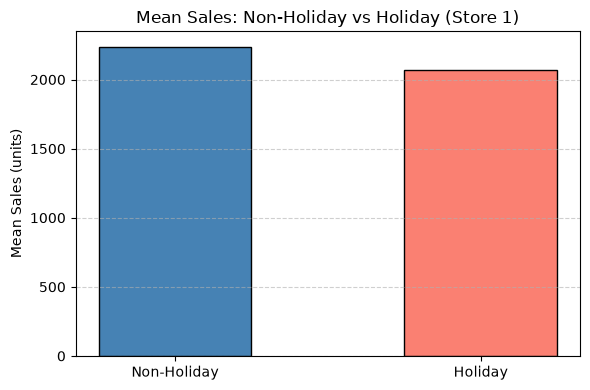

In [23]:
# Holiday vs non-holiday bar plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(holiday_comparison['holiday_label'], holiday_comparison['mean_sales'], color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
ax.set_title('Mean Sales: Non-Holiday vs Holiday (Store 1)')
ax.set_ylabel('Mean Sales (units)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Holiday Observations

- **Mean comparison**: Recorded holidays average ~2,068 units (median ~2,011 units) compared to ~2,237 units (median ~2,294 units) on non-holidays.
- **Higher dispersion**: Standard deviation on holidays ($\sigma pprox 1,422$) is more than double non-holidays ($\sigma pprox 692$). This occurs because holidays comprise two opposing effects: store closures (e.g., New Year's Day with 0 sales) and high-demand festive days or emergency events.
- **Caution**: We should not overstate the direct impact of holidays as a monolithic binary flag; distinct holiday types behave very differently.

## Earthquake Period

On April 16, 2016, a magnitude 7.8 earthquake struck coastal Ecuador. We examine sales behavior during this period.

In [24]:
# All-time maximum sales
max_idx = target_df['sales'].idxmax()
max_row = target_df.loc[max_idx]

# Baseline period immediately before earthquake (March 1 to April 15, 2016)
pre_eq = target_df[(target_df['date'] >= '2016-03-01') & (target_df['date'] < '2016-04-16')]

# Major surge period following earthquake (April 16 to May 15, 2016)
surge_eq = target_df[(target_df['date'] >= '2016-04-16') & (target_df['date'] <= '2016-05-15')]

print(f"Maximum Sales:              {max_row['sales']:.1f} units")
print(f"Date of Maximum Sales:      {max_row['date'].strftime('%Y-%m-%d')}")
print(f"Pre-event baseline mean:    {pre_eq['sales'].mean():.1f} units (median: {pre_eq['sales'].median():.1f})")
print(f"Surge period mean:          {surge_eq['sales'].mean():.1f} units (median: {surge_eq['sales'].median():.1f})")
print(f"Surge vs baseline increase: +{((surge_eq['sales'].mean() / pre_eq['sales'].mean()) - 1) * 100:.1f}%")

Maximum Sales:              9065.0 units
Date of Maximum Sales:      2016-04-18
Pre-event baseline mean:    2422.4 units (median: 2554.5)
Surge period mean:          3201.8 units (median: 2828.0)
Surge vs baseline increase: +32.2%


### Interpretation of the Earthquake Period

- **Observed Behavior**: Sales increased sharply immediately following the April 16, 2016 earthquake, with the series reaching its maximum on April 18. The event should therefore be treated as an external shock when interpreting the series.
- **Numerical Summary**:
  - Pre-event baseline (March 1 to April 15, 2016): mean ~2,422 units (median: ~2,555 units).
  - Surge period (April 16 to May 15, 2016): mean ~3,202 units (median: ~2,828 units), representing an average increase of +32.2%.
  - All-time maximum sales: **9,065 units on April 18, 2016**.
- **Treatment**: We do not remove or modify the earthquake observation. When building forecasting models, treating this event appropriately (e.g., via an external shock indicator or robust loss formulation) will be necessary so models do not erroneously treat the spike as recurring demand.

## Zero Sales

We inspect every date in the target series where recorded sales are zero.

In [25]:
# Extract and inspect all zero-sales days
zero_sales_df = target_df[target_df['sales'] == 0][['date', 'sales', 'onpromotion']].copy()

# Merge with holiday information
zero_sales_info = zero_sales_df.merge(
    holidays_df[['date', 'type', 'locale', 'description']],
    on='date',
    how='left'
)
zero_sales_info

Out[0]: 
        date  sales  onpromotion     type    locale         description
0 2013-01-01    0.0            0  Holiday  National  Primer dia del ano
1 2014-01-01    0.0            0  Holiday  National  Primer dia del ano
2 2015-01-01    0.0            0  Holiday  National  Primer dia del ano
3 2015-07-07    0.0            0      NaN       NaN                 NaN
4 2016-01-01    0.0            0  Holiday  National  Primer dia del ano
5 2017-01-01    0.0            0  Holiday  National  Primer dia del ano


,date,sales,onpromotion,type,locale,description
0,2013-01-01,0.0,0,Holiday,National,Primer dia del ano
1,2014-01-01,0.0,0,Holiday,National,Primer dia del ano
2,2015-01-01,0.0,0,Holiday,National,Primer dia del ano
3,2015-07-07,0.0,0,NaN,NaN,NaN
4,2016-01-01,0.0,0,Holiday,National,Primer dia del ano
5,2017-01-01,0.0,0,Holiday,National,Primer dia del ano


### Importance of Zero-Sales for Forecasting Metrics

- **Summary of dates**: Zero sales occur on exactly 6 dates:
  - Five instances correspond to **January 1 (New Year's Day)** in 2013, 2014, 2015, 2016, and 2017, when stores were closed.
  - July 7, 2015 is an isolated zero-sales observation whose cause is not established by the available data.
- **Impact on Evaluation Metrics**:
  - **MAPE** (Mean Absolute Percentage Error) divides by the actual value:
    $$\text{MAPE} = \frac{1}{n} \sum_{t=1}^n \left| \frac{y_t - \hat{y}_t}{y_t} \right| \times 100\%$$
  - Because MAPE divides by the actual value, it is undefined when actual sales are zero ($y_t = 0$).
  - The target series contains six zero-sales observations.
  - For model evaluation later, MAPE will be calculated on observations where actual sales > 0.
  - **MAE** (Mean Absolute Error) and **RMSE** (Root Mean Squared Error) do not divide by actual values and will be calculated on all test observations.
  - **WAPE** (Weighted Absolute Percentage Error: $\frac{\sum |y_t - \hat{y}_t|}{\sum y_t}$) may optionally be reported as an additional metric.

## Seasonal Decomposition

Time-series decomposition separates an observed series into three additive components:
$$y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Residual}_t$$

- **Observed**: The recorded daily sales.
- **Trend**: The underlying longer-term movement in sales over the 2013–2017 period.
- **Seasonal**: The repeating intra-week fluctuations. For daily retail grocery sales, a **period of 7 days** is the domain-appropriate choice because consumer shopping habits follow a weekly cycle.
- **Residual**: The remaining irregular variation after removing the trend and weekly seasonality (including outliers such as the April 2016 earthquake surge).

We apply `seasonal_decompose` from `statsmodels.tsa.seasonal` using `period=7`.

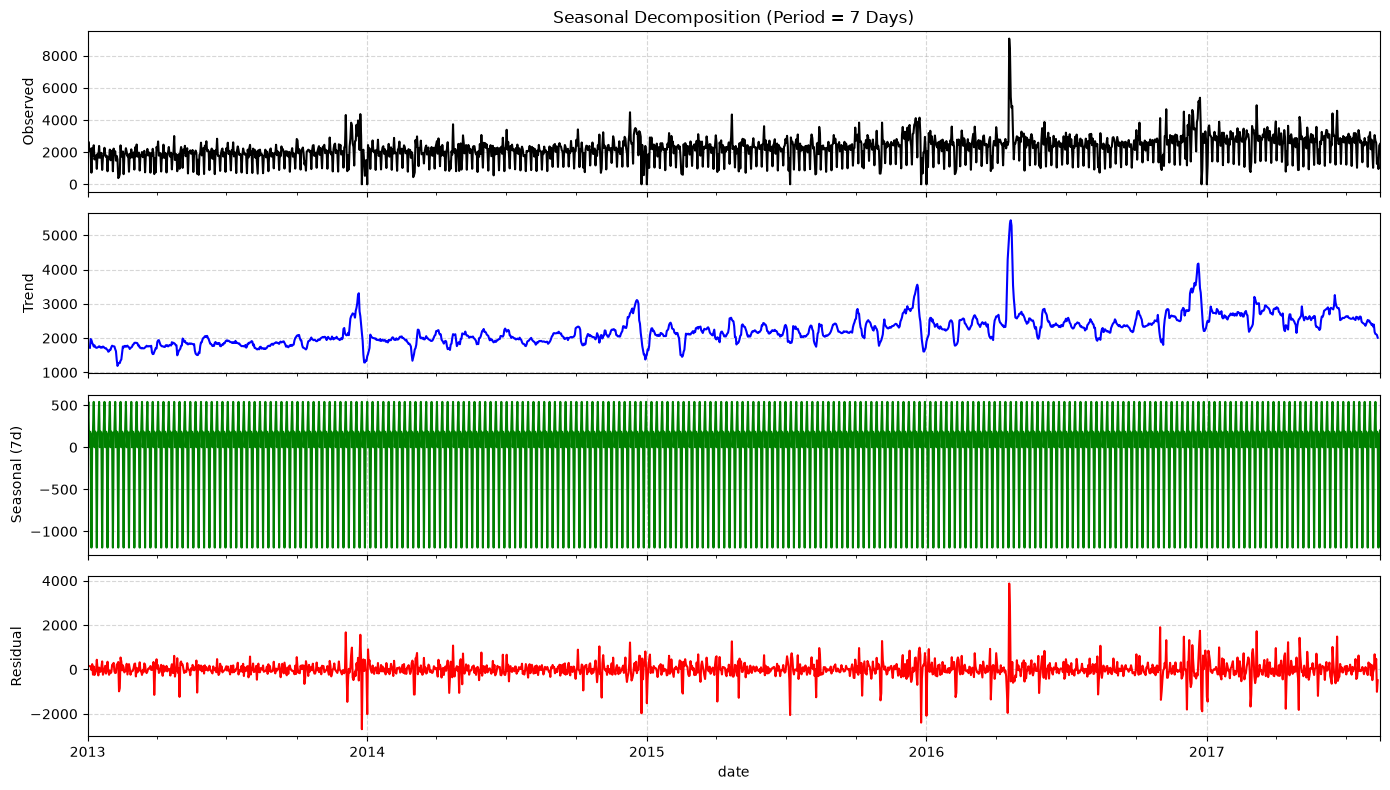

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

# statsmodels seasonal_decompose requires a continuous regular date frequency.
# For decomposition only, we create a temporary contiguous daily series with missing dates filled with 0.
# (Note: target_df itself remains unaltered).
ts_decomp = target_df.set_index('date')['sales'].asfreq('D').fillna(0)

# Decompose using a 7-day weekly retail cycle
decomp = seasonal_decompose(ts_decomp, model='additive', period=7)

# Plot observed, trend, seasonal, and residual components
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

decomp.observed.plot(ax=axes[0], title='Seasonal Decomposition (Period = 7 Days)', color='black')
axes[0].set_ylabel('Observed')
axes[0].grid(True, linestyle='--', alpha=0.5)

decomp.trend.plot(ax=axes[1], color='blue')
axes[1].set_ylabel('Trend')
axes[1].grid(True, linestyle='--', alpha=0.5)

decomp.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal (7d)')
axes[2].grid(True, linestyle='--', alpha=0.5)

decomp.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## EDA Findings

Based on the exploratory analysis of Store 1 GROCERY I daily sales, the key empirical findings are:

1. **Trend**: Sales appear to follow a mild positive long-term drift from 2013 through 2017, rising from an average around ~2,000 units/day to ~2,400 units/day.
2. **Weekly Seasonality**: The series shows strong, clear 7-day weekly seasonality; sales consistently peak on Wednesdays (mean ~2,770 units) and drop sharply on Sundays (mean ~1,031 units).
3. **Monthly Patterns**: December shows the highest monthly average sales (mean ~2,772 units), which coincides with year-end holidays. Outside of December and the April 2016 elevation, other monthly averages remain relatively comparable (between ~2,033 and ~2,269 units); definitive annual seasonality cannot be claimed solely from monthly sample averages.
4. **Promotion Association**: Days with active promotions (`onpromotion > 0`) are associated with higher average sales (~2,404 units) compared to non-promotional days (~1,873 units). Because this is observational data, this indicates an association rather than a causal effect.
5. **Holiday Behavior**: Effective holidays show higher dispersion ($\sigma \approx 1,422$ vs $\sigma \approx 692$ on non-holidays) because holidays include both closures (zero sales) and pre-holiday shopping surges, with overall mean holiday sales (~2,068 units) slightly lower than non-holiday averages (~2,237 units).
6. **Earthquake Outlier**: Sales increased sharply immediately following the April 16, 2016 earthquake, with the series reaching its maximum on April 18. The event should therefore be treated as an external shock when interpreting the series.
7. **Missing Dates**: The four missing dates correspond to Christmas Day. Their treatment will be explicitly defined during the time-series preparation stage rather than being silently imputed during EDA.
8. **Zero-Sales Observations & Metrics**: Exactly six zero-sales dates occur (five on January 1 New Year's Day, and July 7, 2015, an isolated zero-sales observation whose cause is not established by the available data). Because MAPE is undefined when actual sales are zero, MAPE will later be calculated on observations where actual sales > 0, while MAE and RMSE will be evaluated on all test observations.